<a href="https://colab.research.google.com/github/look-crazy/FitGame_WebProgramming/blob/main/gym_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Korean font for matplotlib
!sudo apt-get install -y fonts-nanum-extra && sudo fc-cache -fv && rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-nanum
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-extra
0 upgraded, 2 newly installed, 0 to remove and 24 not upgraded.
Need to get 31.4 MB of archives.
After this operation, 120 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0 MB]
Fetched 31.4 MB in 1s (33.3 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 2.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib to use the installed Korean font
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # Prevents minus sign from breaking

# Reload matplotlib to apply font changes
# This step is crucial after installing new fonts
from IPython.display import clear_output
clear_output(wait=True)
print("Matplotlib font configured.")

Matplotlib font configured.


In [4]:
import pandas as pd

# Load the CSV file into a DataFrame, trying 'euc-kr' encoding
df = pd.read_csv('/content/gym_members_exercise_tracking.csv', encoding='euc-kr')

# Display the first 5 rows of the DataFrame
display(df.head())

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


숫자형 컬럼의 이상치 시각화 (Box Plot):


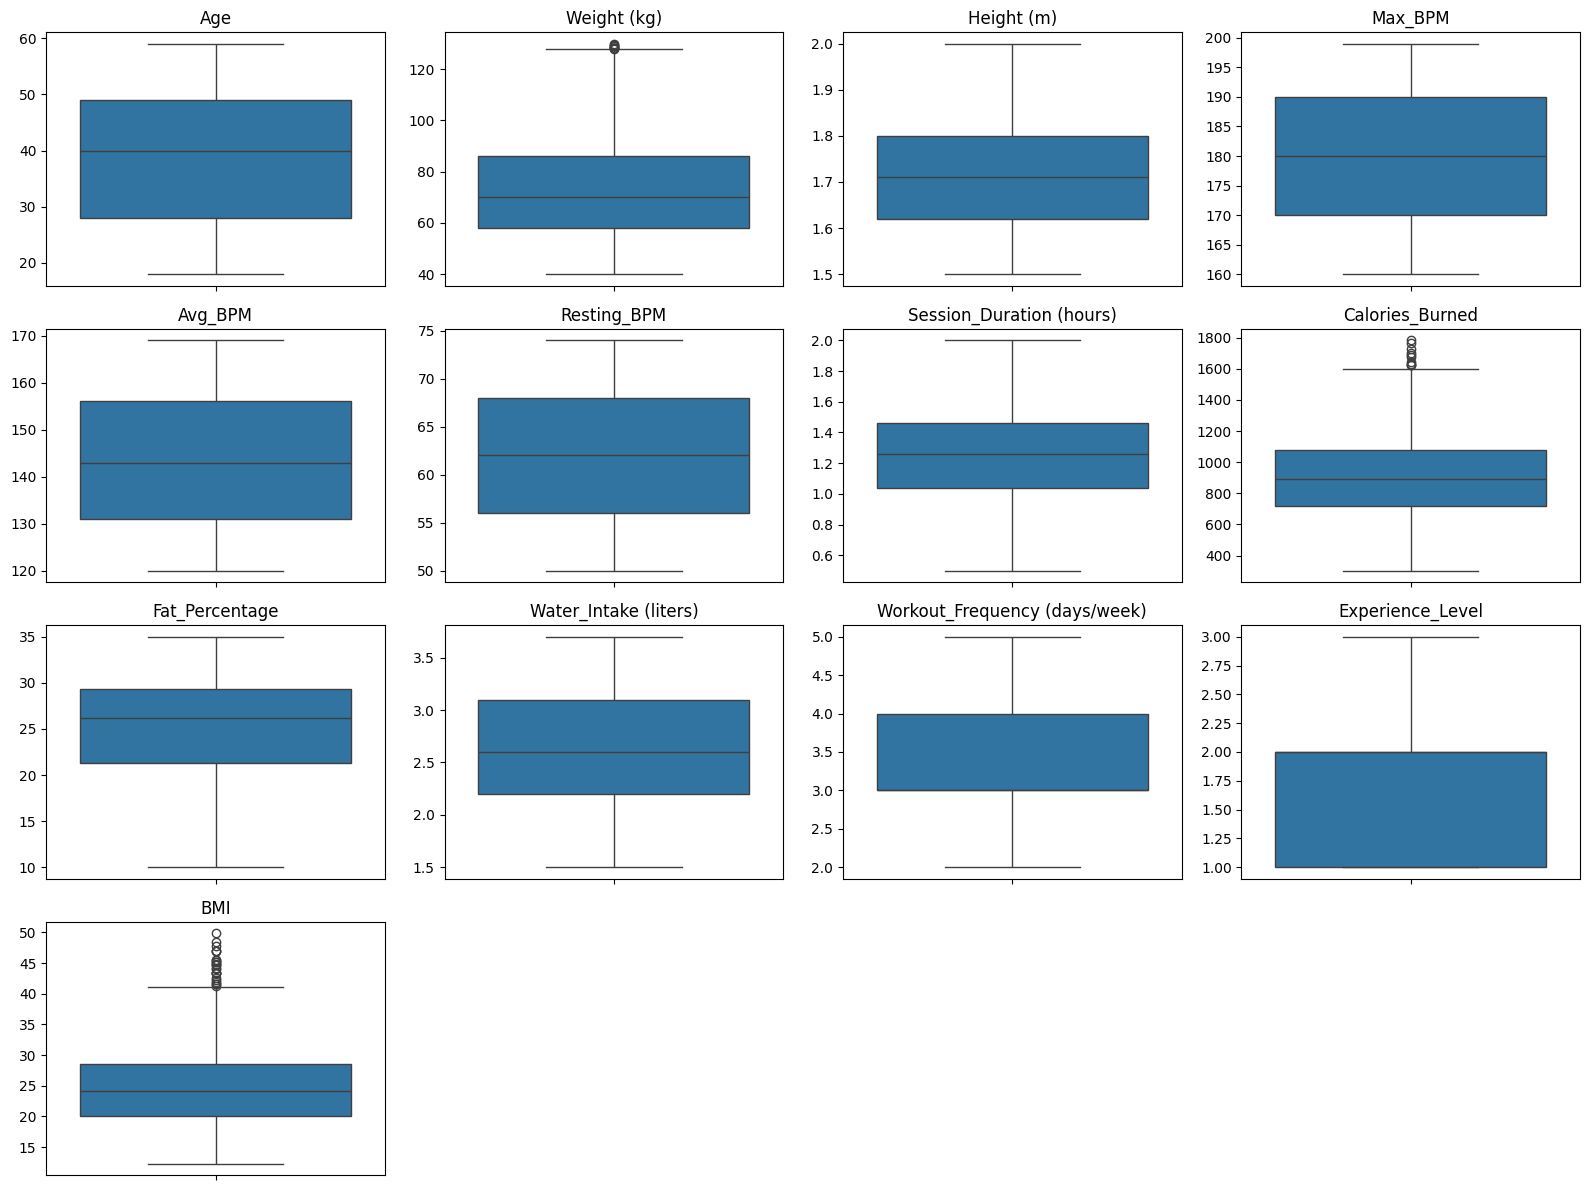

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Configure matplotlib for Korean font
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # Prevents minus sign from breaking

# Identify numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print('숫자형 컬럼의 이상치 시각화 (Box Plot):')

# Calculate number of rows for subplots dynamically
num_plots = len(numerical_cols)
num_cols_in_grid = 4 # You can adjust this value for desired column count
num_rows_in_grid = math.ceil(num_plots / num_cols_in_grid)

plt.figure(figsize=(num_cols_in_grid * 4, num_rows_in_grid * 3)) # Adjust figure size dynamically
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows_in_grid, num_cols_in_grid, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

In [6]:
# Check dataset structure
df.info()

# Display descriptive statistics
display(df.describe(include='all'))

# Count missing values
display(df.isnull().sum().sort_values(ascending=False))

# Count duplicated rows
print('Duplicated rows:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973,973.000000,973.000000,973.000000,973.000000,973.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strength,NaN,NaN,NaN,NaN,NaN
freq,NaN,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258,NaN,NaN,NaN,NaN,NaN
mean,38.683453,NaN,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,NaN,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,NaN,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,NaN,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,NaN,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,NaN,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,NaN,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,NaN,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,NaN,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,NaN,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,NaN,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,NaN,29.300000,3.100000,4.000000,2.000000,28.560000


,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Calories_Burned,0
Workout_Type,0


Duplicated rows: 0


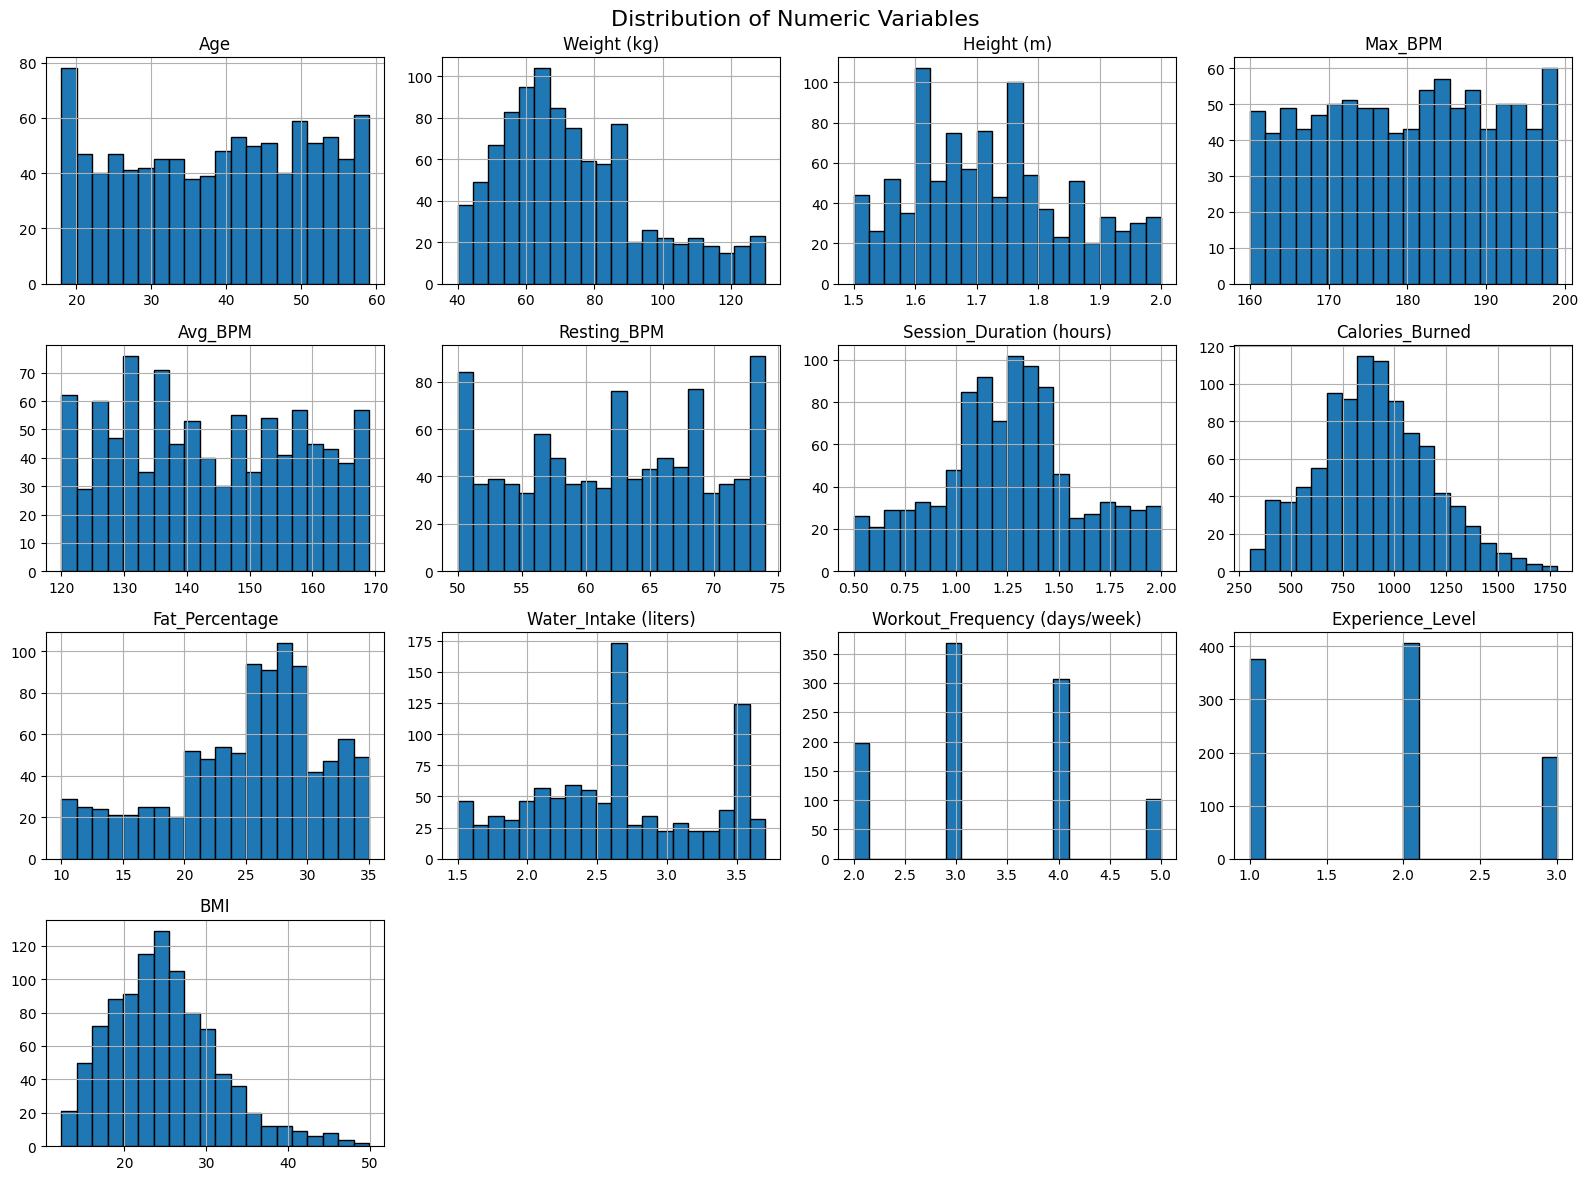

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = df.select_dtypes(include='number').columns

df[numeric_columns].hist(
    figsize=(16, 12),
    bins=20,
    edgecolor='black'
)

plt.suptitle('Distribution of Numeric Variables', fontsize=16)
plt.tight_layout()
plt.show()

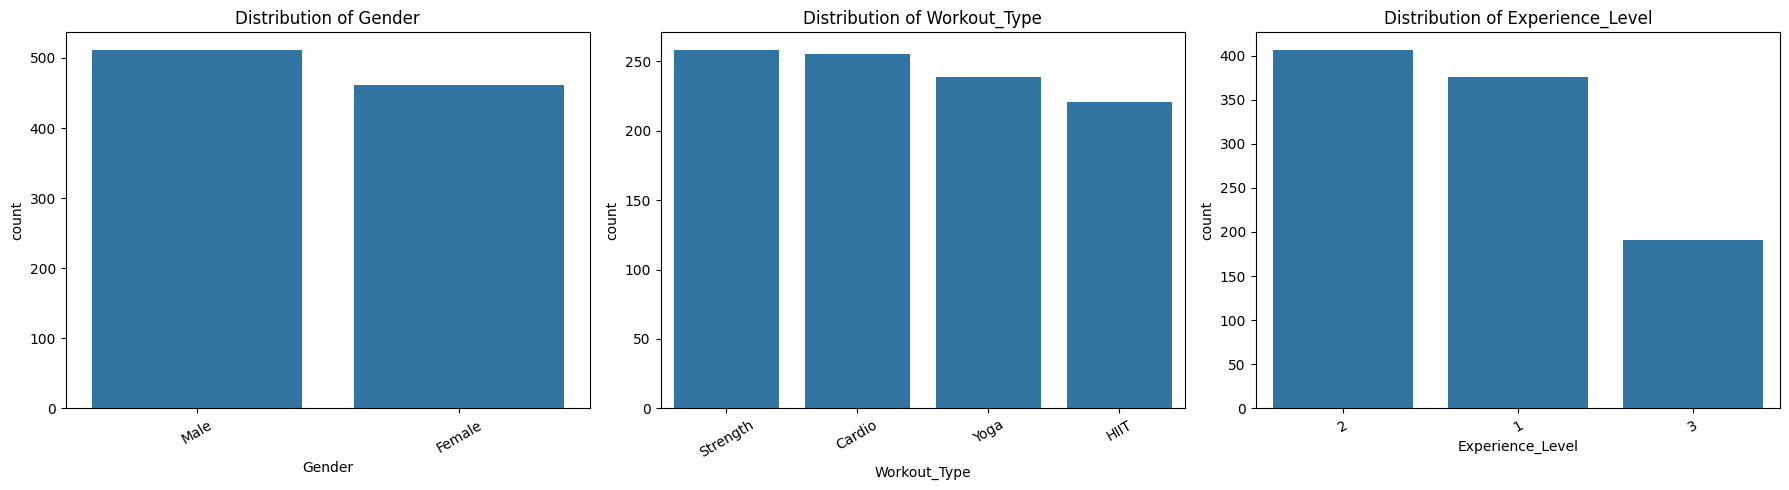

In [8]:
categorical_columns = [
    'Gender',
    'Workout_Type',
    'Experience_Level'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for column, axis in zip(categorical_columns, axes):
    sns.countplot(
        data=df,
        x=column,
        ax=axis,
        order=df[column].value_counts().index
    )
    axis.set_title(f'Distribution of {column}')
    axis.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

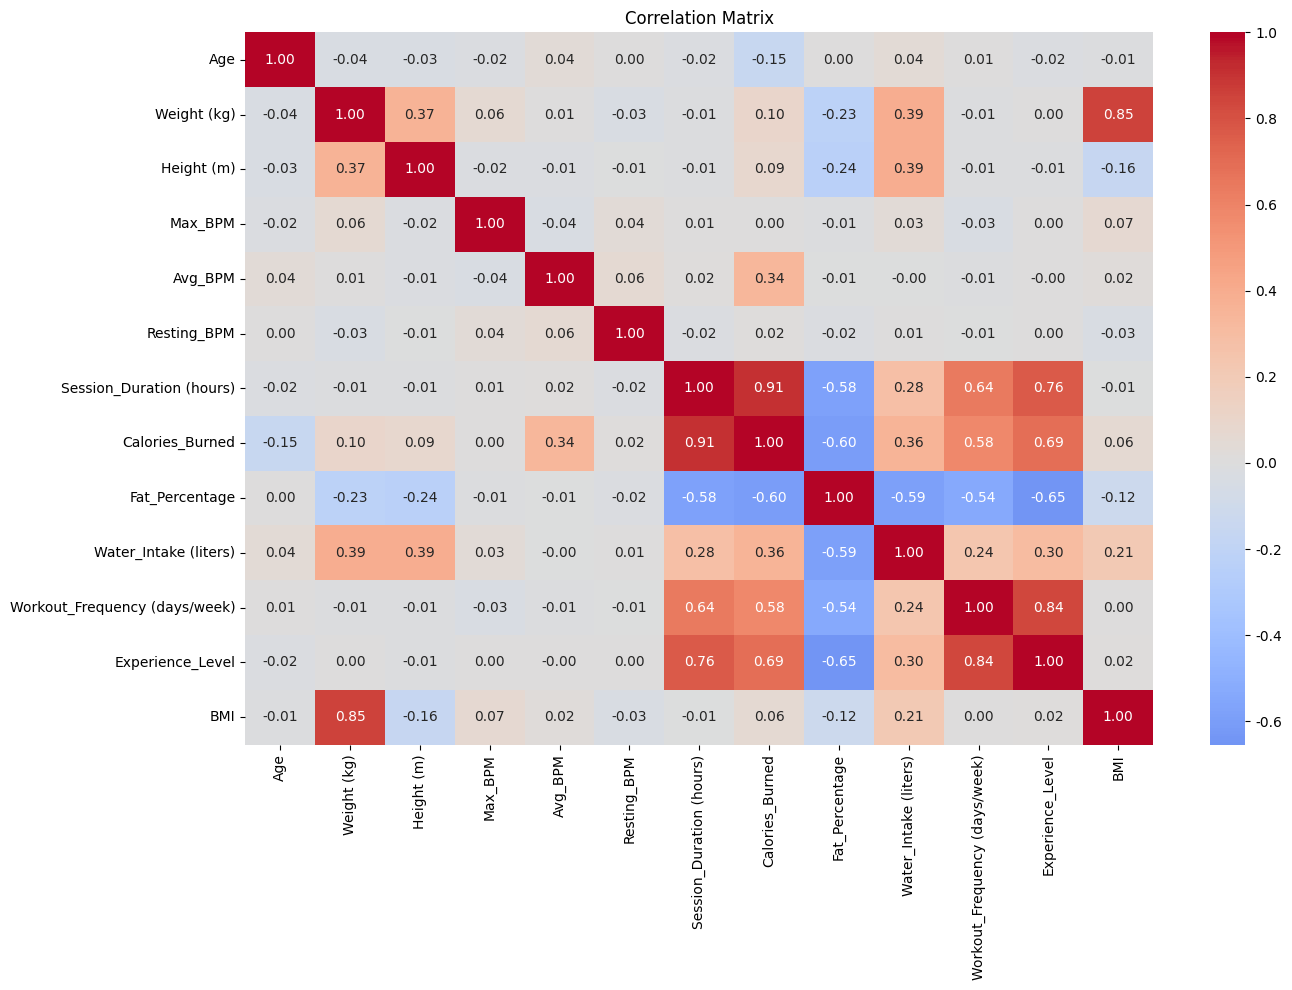

In [9]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

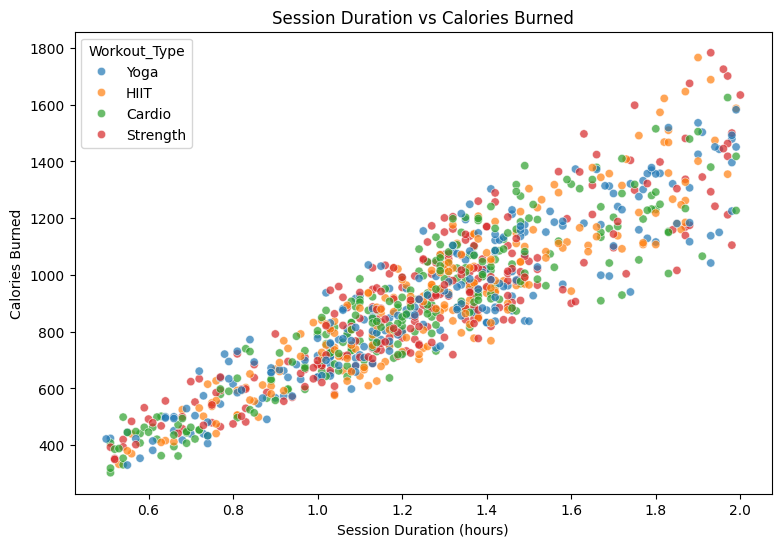

In [10]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Session_Duration (hours)',
    y='Calories_Burned',
    hue='Workout_Type',
    alpha=0.7
)

plt.title('Session Duration vs Calories Burned')
plt.xlabel('Session Duration (hours)')
plt.ylabel('Calories Burned')
plt.show()

In [11]:
gender_summary = df.groupby('Gender')[
    ['Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'BMI']
].mean()

display(gender_summary.round(2))

,Avg_BPM,Session_Duration (hours),Calories_Burned,BMI
Gender,,,,
Female,143.62,1.26,862.25,22.73
Male,143.90,1.25,944.46,26.89


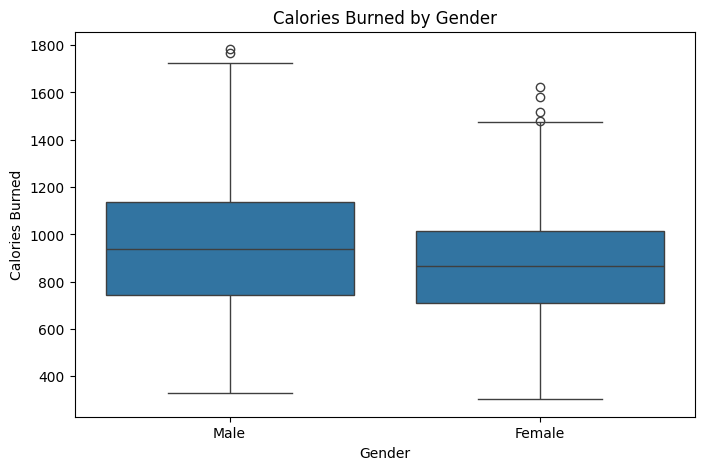

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Gender',
    y='Calories_Burned'
)

plt.title('Calories Burned by Gender')
plt.xlabel('Gender')
plt.ylabel('Calories Burned')
plt.show()

In [13]:
experience_summary = df.groupby('Experience_Level')[
    ['Workout_Frequency (days/week)', 'Session_Duration (hours)', 'Calories_Burned']
].mean()

display(experience_summary.round(2))

,Workout_Frequency (days/week),Session_Duration (hours),Calories_Burned
Experience_Level,,,
1,2.48,1.01,726.38
2,3.53,1.25,901.92
3,4.53,1.76,1265.34


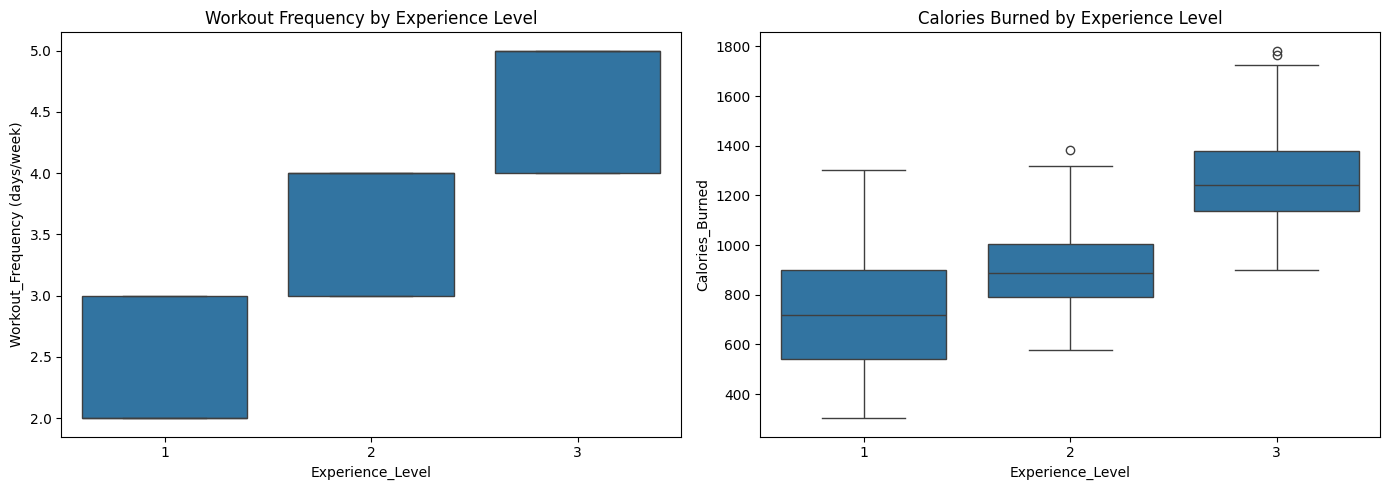

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x='Experience_Level',
    y='Workout_Frequency (days/week)',
    ax=axes[0]
)

sns.boxplot(
    data=df,
    x='Experience_Level',
    y='Calories_Burned',
    ax=axes[1]
)

axes[0].set_title('Workout Frequency by Experience Level')
axes[1].set_title('Calories Burned by Experience Level')

plt.tight_layout()
plt.show()

In [15]:
print('Invalid BPM rows:')
display(
    df[df['Avg_BPM'] > df['Max_BPM']]
)

print('Invalid resting BPM rows:')
display(
    df[df['Resting_BPM'] > df['Avg_BPM']]
)

print('Invalid body composition rows:')
display(
    df[
        (df['BMI'] <= 0) |
        (df['Fat_Percentage'] < 0) |
        (df['Fat_Percentage'] > 100)
    ]
)

Invalid BPM rows:


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
16,19,Female,64.0,1.53,166,167,58,1.33,1111.0,HIIT,29.8,2.3,3,2,27.34
46,24,Male,54.7,1.74,160,167,53,0.84,772.0,Yoga,22.9,3.6,3,1,18.07
56,59,Female,65.5,1.52,161,162,61,1.40,1021.0,Yoga,31.2,2.1,3,2,28.35
95,59,Female,54.6,1.57,164,169,64,0.58,441.0,Cardio,29.2,2.3,3,1,22.15
106,41,Male,71.7,1.96,162,168,51,0.51,424.0,Yoga,27.3,2.5,2,1,18.66
230,28,Male,76.3,1.62,161,162,70,1.16,1034.0,Strength,20.1,2.3,3,2,29.07
310,52,Female,64.9,1.51,164,165,68,1.83,1359.0,HIIT,18.2,2.7,4,3,28.46
326,48,Male,69.0,1.74,160,167,58,1.48,1223.0,HIIT,30.0,2.3,3,2,22.79
356,31,Female,62.5,1.62,168,169,74,1.56,1318.0,HIIT,16.5,2.7,4,3,23.81
365,39,Female,60.6,1.65,162,167,63,0.92,768.0,HIIT,27.6,1.7,3,1,22.26


Invalid resting BPM rows:


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI


Invalid body composition rows:


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI


In [16]:
# Calculate calories burned per minute
df['Calories_Per_Minute'] = (
    df['Calories_Burned'] /
    (df['Session_Duration (hours)'] * 60)
)

# Calculate the average calories per minute by workout type
calories_per_minute_by_workout = (
    df.groupby('Workout_Type')['Calories_Per_Minute']
    .mean()
    .sort_values(ascending=False)
)

display(calories_per_minute_by_workout)

,Calories_Per_Minute
Workout_Type,
Strength,12.066584
Cardio,12.064133
Yoga,11.941987
HIIT,11.941918


In [17]:
#음... 근데 이러면 그냥 운동 오래하면 칼로리 소모가 높은건데 뭔가 무조건 높진 않을 것 같단 말이지;;
# 총 칼로리 소모량은 운동시간이 길거나 체중이 많이 나갈수록 높아지겠지? 운동시간과 체중의 영향을 보정하여 개인별 운동 효율을 공정하게 비교함.
# Calculate calories burned per minute
df['Calories_Per_Minute'] = (
    df['Calories_Burned'] /
    (df['Session_Duration (hours)'] * 60)
)

# Calculate calories burned per minute per kilogram
df['Calories_Per_Minute_Per_Kg'] = (
    df['Calories_Burned'] /
    (df['Session_Duration (hours)'] * 60 * df['Weight (kg)'])
)

# Calculate heart rate reserve utilization
df['Heart_Rate_Reserve_Utilization'] = (
    (df['Avg_BPM'] - df['Resting_BPM']) /
    (df['Max_BPM'] - df['Resting_BPM'])
)

In [18]:
#개인·운동 정보
#→ 예상 칼로리 예측
#→ 실제 칼로리와 비교
#→ Efficiency Score 계산
# 나이, 성별, 체중, 키, 평균 심박수, 안정 심박수, 운동시간, 운동 종류를 활용하여 개인별 예상 칼로리 소모량을 예측한다.
# 이후 실제 칼로리 소모량에서 예상 칼로리 소모량을 뺀 값을 운동 효율 점수로 정의하여, 비슷한 조건의 사람보다 칼로리를 얼마나 더 많이 또는 적게 소모했는지 분석한다.
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

feature_columns = [
    'Age',
    'Gender',
    'Weight (kg)',
    'Height (m)',
    'Avg_BPM',
    'Resting_BPM',
    'Session_Duration (hours)',
    'Workout_Type'
]

X = df[feature_columns]
y = df['Calories_Burned']

categorical_columns = ['Gender', 'Workout_Type']
numeric_columns = [
    column for column in feature_columns
    if column not in categorical_columns
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_columns
        ),
        (
            'numeric',
            'passthrough',
            numeric_columns
        )
    ]
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'regressor',
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, predictions))
print('R-squared:', r2_score(y_test, predictions))

MAE: 32.924461538461536
R-squared: 0.9760494307890423


In [19]:
#단순히 칼로리가 높은 사람이 아니라, 조건을 보정한 뒤에도 성과가 높은 사람
df['Expected_Calories'] = model.predict(X)

df['Efficiency_Score'] = (
    df['Calories_Burned'] -
    df['Expected_Calories']
)

high_efficiency_members = df.nlargest(
    10,
    'Efficiency_Score'
)

display(
    high_efficiency_members[
        [
            'Age',
            'Gender',
            'Workout_Type',
            'Session_Duration (hours)',
            'Avg_BPM',
            'Calories_Burned',
            'Expected_Calories',
            'Efficiency_Score'
        ]
    ]
)

,Age,Gender,Workout_Type,Session_Duration (hours),Avg_BPM,Calories_Burned,Expected_Calories,Efficiency_Score
736,27,Male,Strength,1.75,166,1598.0,1396.453333,201.546667
66,32,Male,HIIT,1.99,145,1587.0,1424.733333,162.266667
712,19,Male,HIIT,1.90,169,1766.0,1610.616667,155.383333
801,24,Male,HIIT,1.76,154,1491.0,1375.016667,115.983333
728,47,Male,Strength,2.00,165,1634.0,1527.426667,106.573333
513,36,Male,Yoga,1.98,137,1492.0,1386.480000,105.520000
968,24,Male,Strength,1.57,158,1364.0,1277.136667,86.863333
55,23,Male,Cardio,1.47,163,1318.0,1233.950000,84.050000
44,37,Male,HIIT,1.50,158,1304.0,1223.583333,80.416667
481,28,Male,Strength,1.05,166,959.0,885.740000,73.260000


In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

clustering_columns = [
    'Workout_Frequency (days/week)',
    'Session_Duration (hours)',
    'Avg_BPM',
    'Calories_Per_Minute_Per_Kg',
    'Heart_Rate_Reserve_Utilization',
    'Fat_Percentage'
]

scaled_data = StandardScaler().fit_transform(
    df[clustering_columns]
)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Workout_Profile'] = kmeans.fit_predict(scaled_data)

profile_summary = df.groupby('Workout_Profile')[
    clustering_columns
].mean().round(2)

display(profile_summary)

,Workout_Frequency (days/week),Session_Duration (hours),Avg_BPM,Calories_Per_Minute_Per_Kg,Heart_Rate_Reserve_Utilization,Fat_Percentage
Workout_Profile,,,,,,
0,4.53,1.76,142.93,0.17,0.69,14.85
1,2.97,1.15,155.49,0.25,0.81,28.15
2,3.00,1.11,131.90,0.15,0.59,27.26
3,3.11,1.16,156.76,0.16,0.82,27.22


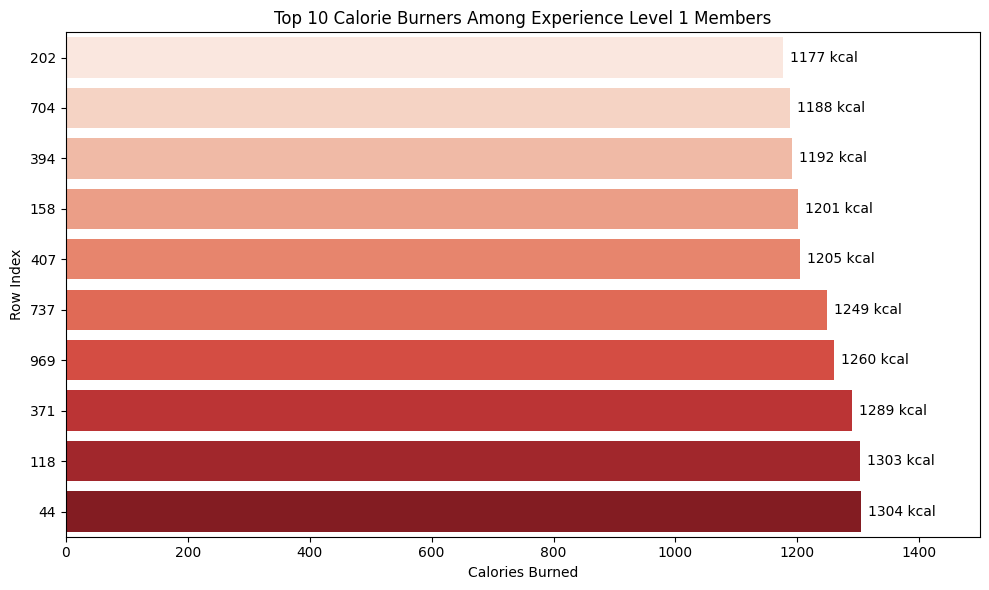

,Member_Index,Age,Gender,Workout_Type,Session_Duration (hours),Avg_BPM,Calories_Burned
44,44,37,Male,HIIT,1.50,158,1304.0
118,118,18,Male,Yoga,1.41,168,1303.0
371,371,32,Male,Strength,1.42,165,1289.0
969,969,25,Male,Strength,1.38,166,1260.0
737,737,34,Male,Yoga,1.36,167,1249.0
407,407,39,Male,Strength,1.32,166,1205.0
158,158,18,Male,Strength,1.30,168,1201.0
394,394,40,Male,Cardio,1.38,157,1192.0
704,704,47,Male,HIIT,1.42,169,1188.0
202,202,22,Female,Yoga,1.49,158,1177.0


In [21]:
#고강도 인터벌이 운동경험수준이 낮은 사람이네? 이것도 신기하네
import matplotlib.pyplot as plt
import seaborn as sns

# Filter members with Experience Level 1
level_1_members = df[
    df['Experience_Level'] == 1
].copy()

# Select the top 10 members by calories burned
top_n = 10

top_calorie_burners = (
    level_1_members
    .nlargest(top_n, 'Calories_Burned')
    .sort_values('Calories_Burned')
)

# Create row index labels
top_calorie_burners['Member_Index'] = (
    top_calorie_burners.index.astype(str)
)

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_calorie_burners,
    x='Calories_Burned',
    y='Member_Index',
    hue='Member_Index',
    palette='Reds',
    legend=False
)

# Display calorie values on each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f kcal',
        padding=5
    )

plt.title('Top 10 Calorie Burners Among Experience Level 1 Members')
plt.xlabel('Calories Burned')
plt.ylabel('Row Index')
plt.xlim(
    0,
    top_calorie_burners['Calories_Burned'].max() * 1.15
)

plt.tight_layout()
plt.show()

# Display detailed information
display(
    top_calorie_burners[
        [
            'Member_Index',
            'Age',
            'Gender',
            'Workout_Type',
            'Session_Duration (hours)',
            'Avg_BPM',
            'Calories_Burned'
        ]
    ].sort_values(
        'Calories_Burned',
        ascending=False
    )
)

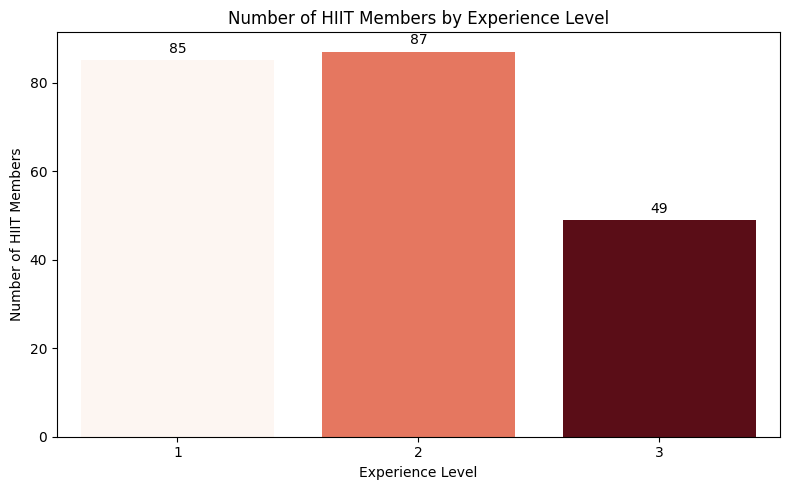

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count HIIT members by experience level
hiit_counts = (
    df[df['Workout_Type'] == 'HIIT']
    ['Experience_Level']
    .value_counts()
    .sort_index()
    .reset_index()
)

hiit_counts.columns = [
    'Experience_Level',
    'HIIT_Count'
]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=hiit_counts,
    x='Experience_Level',
    y='HIIT_Count',
    hue='Experience_Level',
    palette='Reds',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3
    )

plt.title('Number of HIIT Members by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Number of HIIT Members')
plt.tight_layout()
plt.show()

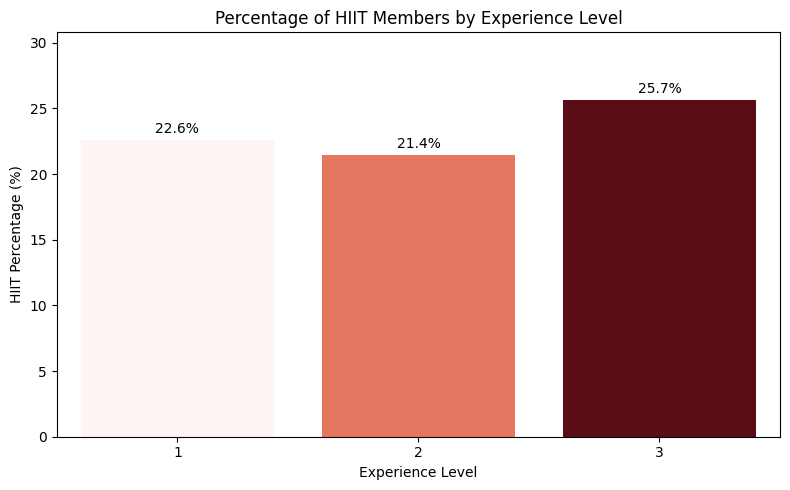

,Experience_Level,HIIT_Percentage
0,1,22.606383
1,2,21.428571
2,3,25.654450


In [23]:
# Calculate the percentage of HIIT members within each experience level
hiit_rate = (
    df.assign(
        Is_HIIT=df['Workout_Type'].eq('HIIT')
    )
    .groupby('Experience_Level')['Is_HIIT']
    .mean()
    .mul(100)
    .reset_index()
)

hiit_rate.columns = [
    'Experience_Level',
    'HIIT_Percentage'
]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=hiit_rate,
    x='Experience_Level',
    y='HIIT_Percentage',
    hue='Experience_Level',
    palette='Reds',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.title('Percentage of HIIT Members by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('HIIT Percentage (%)')
plt.ylim(
    0,
    hiit_rate['HIIT_Percentage'].max() * 1.2
)

plt.tight_layout()
plt.show()

display(hiit_rate)

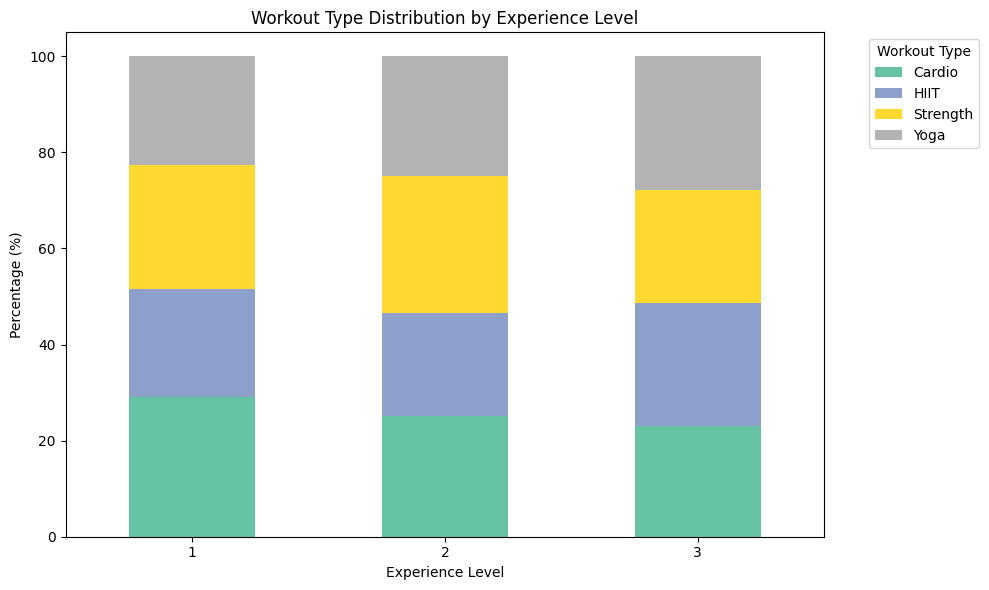

Workout_Type,Cardio,HIIT,Strength,Yoga
Experience_Level,,,,
1,28.99,22.61,25.80,22.61
2,25.12,21.43,28.57,24.88
3,23.04,25.65,23.56,27.75


In [24]:
# Create a normalized cross-tabulation
workout_percentage = pd.crosstab(
    df['Experience_Level'],
    df['Workout_Type'],
    normalize='index'
).mul(100)

# Create a 100% stacked bar chart
workout_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='Set2'
)

plt.title('Workout Type Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(
    title='Workout Type',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

display(workout_percentage.round(2))

In [25]:
from scipy.stats import chi2_contingency

# Create a frequency table
contingency_table = pd.crosstab(
    df['Experience_Level'],
    df['Workout_Type']
)

# Perform the chi-square test
chi2, p_value, degrees_of_freedom, expected_counts = (
    chi2_contingency(contingency_table)
)

print(f'Chi-square statistic: {chi2:.3f}')
print(f'P-value: {p_value:.4f}')
print(f'Degrees of freedom: {degrees_of_freedom}')

Chi-square statistic: 5.790
P-value: 0.4471
Degrees of freedom: 6


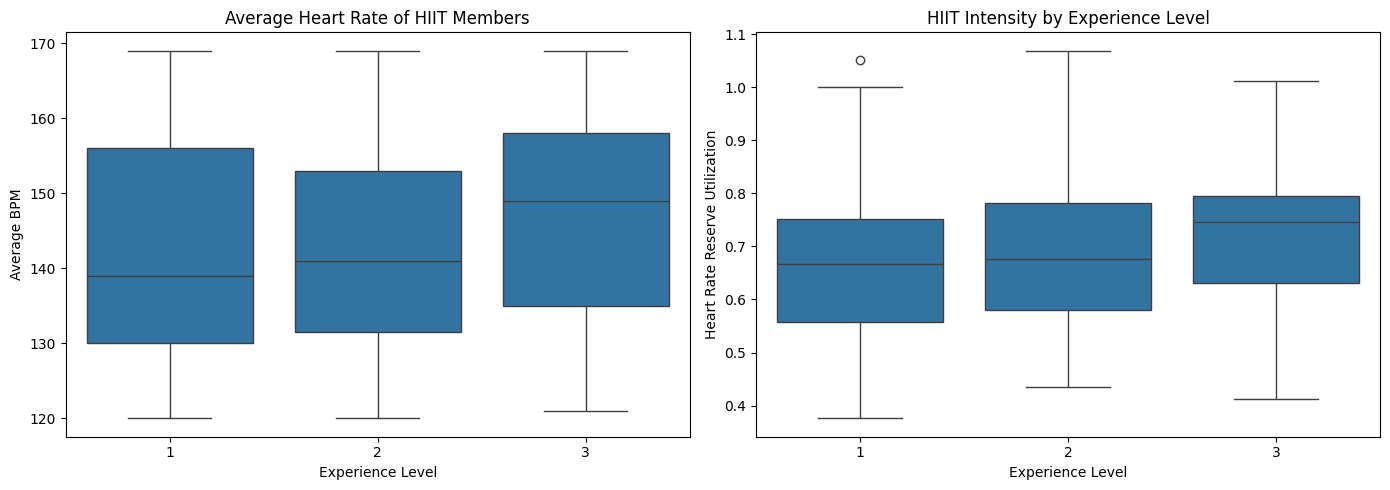

In [26]:
# Calculate heart rate reserve utilization
df['Heart_Rate_Reserve_Utilization'] = (
    (df['Avg_BPM'] - df['Resting_BPM']) /
    (df['Max_BPM'] - df['Resting_BPM'])
)

# Select HIIT members
hiit_members = df[
    df['Workout_Type'] == 'HIIT'
].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.boxplot(
    data=hiit_members,
    x='Experience_Level',
    y='Avg_BPM',
    ax=axes[0]
)

sns.boxplot(
    data=hiit_members,
    x='Experience_Level',
    y='Heart_Rate_Reserve_Utilization',
    ax=axes[1]
)

axes[0].set_title('Average Heart Rate of HIIT Members')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Average BPM')

axes[1].set_title('HIIT Intensity by Experience Level')
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Heart Rate Reserve Utilization')

plt.tight_layout()
plt.show()

In [27]:
## 결론

#본 분석은 헬스장 이용자 973명의 신체 정보와 운동 기록을 바탕으로 운동 종류, 운동 경험 수준, 운동시간이 칼로리 소모량과 어떠한 관계를 갖는지 분석하였다.

#첫째, 총 칼로리 소모량은 운동 종류보다 운동시간의 영향을 크게 받는 것으로 나타났다. 운동시간과 칼로리 소모량의 상관계수는 약 0.91로 매우 높은 양의 관계를 보였다.
#따라서 총 칼로리만으로 운동 효율을 판단하면 오래 운동한 사람이 더 효율적으로 보이는 착시가 발생할 수 있다.
#이를 보완하기 위해 분당 칼로리와 체중당 분당 칼로리를 추가로 계산하였다.

#둘째, 운동 종류별 평균 분당 칼로리는 Strength 12.067, Cardio 12.064, Yoga 11.942, HIIT 11.942 kcal로 큰 차이가 나타나지 않았다.
#특히 HIIT는 일부 칼로리 소모 및 운동 효율 상위 사례에서 자주 관찰되었지만, 전체 평균에서는 다른 운동보다 높은 분당 칼로리를 보이지 않았다.
#따라서 HIIT가 모든 사람에게 가장 높은 칼로리 효율을 제공한다고 일반화하기보다는, 특정 개인이나 고강도로 수행된 세션에서 높은 성과가 나타날 가능성이 있다고 해석하는 것이 적절하다.

#셋째, 운동 경험 수준에 따른 차이는 매우 뚜렷하게 나타났다.
#경험 수준 1, 2, 3의 주당 평균 운동 빈도는 각각 2.48일, 3.53일, 4.53일이었으며, 평균 운동시간도 1.01시간, 1.25시간, 1.76시간으로 증가하였다.
#이에 따라 평균 칼로리 소모량 역시 726.38kcal, 901.92kcal, 1,265.34kcal로 단계적으로 증가하였다.
#이는 숙련자일수록 한 번의 운동 강도만 높은 것이 아니라 더 자주, 더 오래 운동하는 지속적인 운동 습관을 형성하고 있음을 보여준다.

#넷째, 세션별로 칼로리 소모 시각화를 보니 각 시간마다 최상위권에 고강도 인터벌이 있다는것을 확인함.
#초보자 집단의 칼로리 소모 상위 10명 중 HIIT 참여자가 포함되어 있어 초보자도 고강도 운동을 수행할 수 있다는 사례를 확인하였다.
#그러나 경험 수준별 HIIT 참여 비율은 수준 1이 22.61%, 수준 2가 21.43%, 수준 3이 25.65%로 수준 3에서 가장 높았다.
#또한 경험 수준과 운동 종류에 대한 카이제곱 검정의 p-value는 0.4471로 나타나, 두 변수 사이에 통계적으로 유의한 관련성이 있다고 보기 어려웠다.
#따라서 초보자가 HIIT를 더 선호한다고 결론 내릴 수는 없으며, 초보자 중에서도 높은 칼로리를 소모한 HIIT 사례가 존재한다고 해석해야 한다.

#마지막으로 개인의 신체조건과 운동정보를 이용한 칼로리 예측 모델은 R² 0.976, MAE 약 32.92kcal의 높은 예측 성능을 보였다.
#이는 운동시간, 평균 심박수, 체중 등의 정보만으로도 칼로리 소모량 대부분을 설명할 수 있음을 의미한다.
#실제 칼로리와 예상 칼로리의 차이를 운동 효율 점수로 계산한 결과, 고효율 상위 10명 중 HIIT 참여자가 4명 포함되어 HIIT가 일부 개인에게 높은 성과를 낼 가능성을 확인하였다.

#종합하면, 칼로리 소모를 결정하는 핵심은 특정 운동 종류 하나가 아니라 개인의 운동시간, 신체조건, 심박수, 그리고 경험 수준에 따라 형성된 운동 빈도와 지속성의 조합이라고 볼 수 있다.
#특히 숙련자는 단순히 더 강한 운동을 선택하는 것이 아니라 더 자주, 더 오래 운동함으로써 높은 칼로리 소모를 달성하였다.
#따라서 개인에게 적합한 운동을 선택한 뒤 경험 수준에 맞게 운동 빈도와 지속시간을 점진적으로 높이는 것이 장기적인 운동 성과에 더 중요하다고 판단된다.